In [123]:
## information about how to use the script
import sys
sys.path.append('/home/steven/Documents/FiLMScope-sjt')

from filmscope.recon_util import (add_sample_entry, get_all_sample_names,
                                  get_ss_volume_from_dataset)
from filmscope.util import play_video, load_dictionary
from filmscope.calibration import CalibrationInfoManager
from filmscope.datasets import FSDataset
import os
from matplotlib import pyplot as plt
import numpy as np
import xarray as xr
from filmscope.config import path_to_data

import torch

In [124]:
# view already saved samples 
get_all_sample_names()

-1

In [125]:
# optional: select GPU to be used
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [126]:
# necessary information about the dataset 
sample_name = "data/phantom" 
# this is the data's location within "path_to_data"
folder = "data/phantom" 
image_filename = folder + '/phantom_20260108_164314_254.nc'

# frame number that will be viewed for videos
# set to -1 for images
frame_number = -1

calibration_filename = folder + '/calibration_information'
# blank images can be used to remove illumination artifacts
# set to None if this was not acquired
blank_filename = None # folder + "/blank_image.nc" 
bf = blank_filename 
if bf is not None:
    bf = path_to_data + '/' + bf

print(path_to_data)
print(calibration_filename)

/home/steven/Documents/FiLMScope-sjt
data/phantom/calibration_information


In [127]:
# some datasets were calibrated without saving the image shape used to calibrate
# this cell can be used to address that
manager = CalibrationInfoManager(path_to_data + '/' + calibration_filename)
if manager.image_shape is None:
    if manager.is_single_image:
        idx = manager.crop_indices[0]
        manager.image_shape = (idx[1] - idx[0], idx[3] - idx[2])
    else:
        print("adding image shape")
        dataset = xr.open_dataset(path_to_data + '/' + image_filename)
        downsample = int(dataset.y[1] - dataset.y[0])
        image_shape = (len(dataset.x) * downsample, len(dataset.y) * downsample)
        manager.image_shape = image_shape 
    manager.save_all_info()

In [128]:
# set up a dataset with just the reference image 
ref_camera = CalibrationInfoManager(path_to_data + '/' + calibration_filename).reference_camera
downsample = 4
image_numbers = [ref_camera]
dataset = FSDataset(
    {}, path_to_data + '/' + calibration_filename,
    image_numbers,
    image_filename = path_to_data + '/' + image_filename,
    downsample = downsample,
    crop_values = (0, 1, 0, 1),
    enforce_divisible=-1,
    frame_number=frame_number,
    blank_filename=bf
)

loading images: 100%|██████████| 1/1 [00:00<00:00, 267.19it/s]


torch.Size([1, 768, 768])


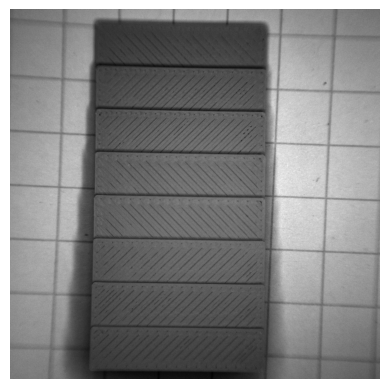

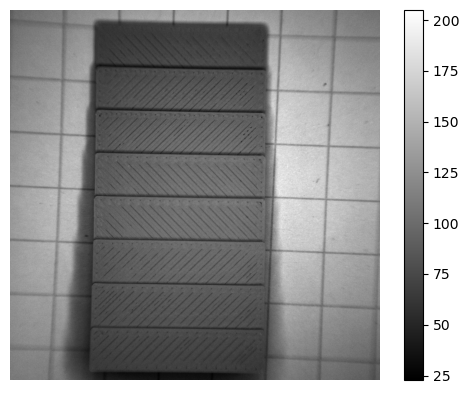

In [131]:
# pick a crop level that shows the desired FOV
print(dataset.reference_image.shape)
crop = (0, 768, 0, 768) 
full_image = np.squeeze(dataset.reference_image)
crop_image = full_image[crop[0] : crop[1], crop[2] : crop[3]]

plt.imshow(crop_image, cmap = 'gray')
plt.axis('off')

plt.figure()
plt.imshow(full_image, cmap = 'gray')
plt.axis('off')
plt.colorbar()

In [85]:
# determine crop values
shape0 = dataset.images.shape[2]
shape1 = dataset.images.shape[3]

crop_values = (
    crop[0] / shape0,
    crop[1] / shape0,
    crop[2] / shape1,
    crop[3] / shape1,
)
print(crop_values)

(0.0, 1.0, 0.0, 1.0)


In [86]:
dataset = None

# new dataset with the crops
downsample = 4
image_numbers = manager.image_numbers

dataset = FSDataset(
    {}, path_to_data + '/' + calibration_filename,
    image_numbers,
    image_filename = path_to_data + '/' + image_filename,
    downsample = downsample,
    crop_values = crop_values,
    enforce_divisible=-1,
    frame_number=frame_number,
    blank_filename=bf
)


loading images: 100%|██████████| 36/36 [00:00<00:00, 174.16it/s]


torch.Size([768, 768])


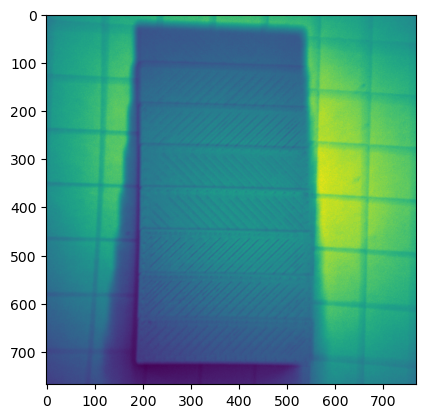

In [87]:
img = dataset.images[0].squeeze()
plt.imshow((img - img.min()) / (img.max() - img.min()))
print(img.shape)

In [120]:
# find depth extents
low_plane = -5#-64
high_plane = 10#200

num = 32
depths = np.linspace(low_plane, high_plane, num, endpoint=True)
depth_values = torch.from_numpy(depths).to(torch.float32).cuda()

batch_size = 12
volume = get_ss_volume_from_dataset(dataset, batch_size, depth_values, get_squared=False)
volume = volume.squeeze().cpu().numpy()

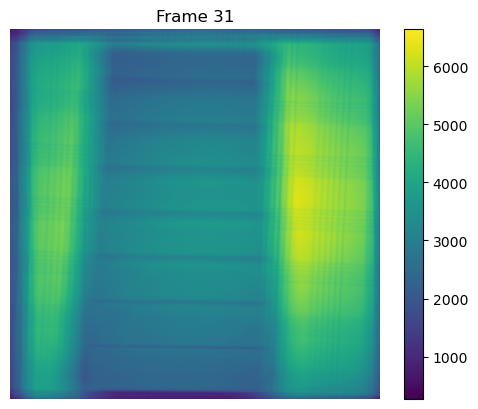

In [122]:
play_video(volume, fps = 5)

Text(0.5, 1.0, '15.00 mm')

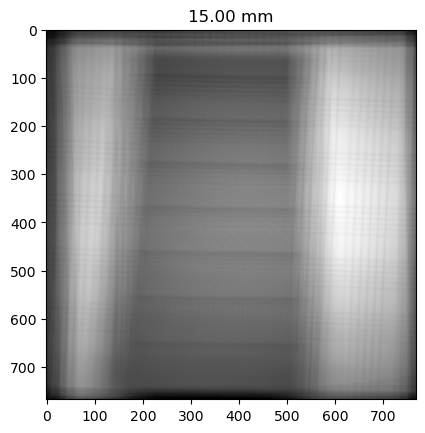

In [98]:
idx = -1
plt.imshow(volume[idx], cmap='gray')
plt.title("{:.2f} mm".format(depths[idx]))

In [63]:
# make the full sample entry
info = {
    "folder": folder,
    "sample_name": sample_name,
    "calibration_filename": calibration_filename,
    "image_filename": image_filename,
    "crop_values": crop_values,
    "depth_range": (low_plane, high_plane),
    "blank_filename": blank_filename,
}
print(info)

{'folder': 'data/phantom', 'sample_name': 'data/phantom', 'calibration_filename': 'data/phantom/calibration_information', 'image_filename': 'data/phantom/phantom_20260108_153511_451.nc', 'crop_values': (0.0, 1.0, 0.0, 1.0), 'depth_range': (0, 64), 'blank_filename': None}


In [ ]:
# and save it!
# this cell is commented out for the demo

add_sample_entry(sample_name, info, overwrite=False)